**In linear regression, high correlation between covariates (multicollinearity) does not necessarily hurt predictive performance, but it can make the interpretation of coefficients difficult.**

See correlation_lin_reg.pdf for the gaussian case. 




    
     
 
  

In [48]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Set random seed for reproducibility



rng=np.random.default_rng(seed=4)


def simu(n_samples=100,n_simulations=1000,corr=0):

    coefficients = []
    test_error=[]

    N=int(n_samples*1.3)
    
    for _ in range(n_simulations):
        # Generate synthetic data
        cov_matrix=[[1,corr],[corr,1]]
        X=rng.multivariate_normal(mean=[0,0], cov=cov_matrix,size=N)
        y = 3 * X[:,0] + 2 * X[:,1] + rng.normal(0, 0.1, N)
        
        Xtrain=X[:n_samples,:]
        Xtest=X[n_samples:,:]
        ytrain=y[:n_samples]
        ytest=y[n_samples:]
    
        # Fit linear regression model
        model = LinearRegression().fit(Xtrain, ytrain)
        
        # Store coefficients
        coefficients.append(model.coef_)

        # prediction and test error
        ypred = model.predict(Xtest)
        test_error.append(mean_squared_error(ytest, ypred))
    
    coefficients = np.array(coefficients)
    test_error=np.array(test_error)
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.delaxes(axes[1, 1]) 

    axes[0,0].hist(coefficients[:, 0], bins=30, alpha=0.7, color='blue')
    axes[0,0].set_title('Histogram of Coefficient for X1')
    axes[0,0].set_xlabel('Coefficient Value')
    axes[0,0].set_ylabel('Frequency')

    axes[0,1].hist(coefficients[:, 1], bins=30, alpha=0.7, color='green')
    axes[0,1].set_title('Histogram of Coefficient for X2')
    axes[0,1].set_xlabel('Coefficient Value')
    axes[0,1].set_ylabel('Frequency')

    axes[1,0].hist(test_error, bins=30, alpha=0.7, color='red')
    axes[1,0].set_title('Histogram of the test error')
    axes[1,0].set_xlabel('test error')
    axes[1,0].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    return(np.linalg.cond(X),test_error.mean())

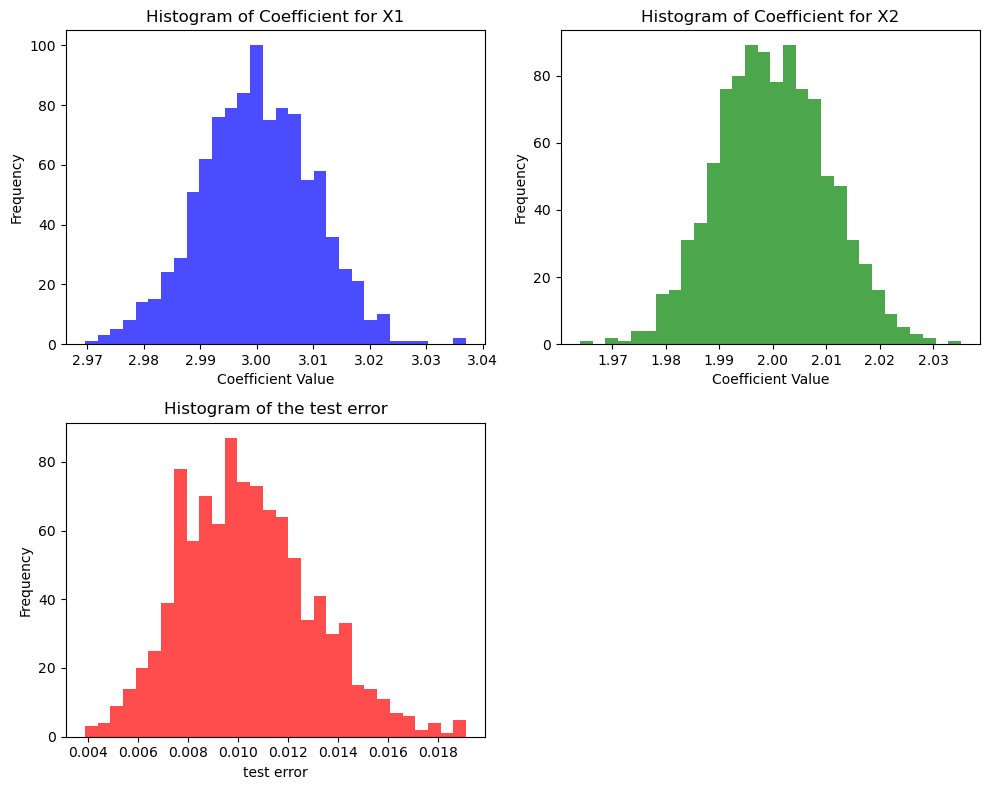

(1.1474466382986703, 0.010403160554401924)

In [49]:
# without correlation : pay attention to the x-scale !
simu(corr=0)

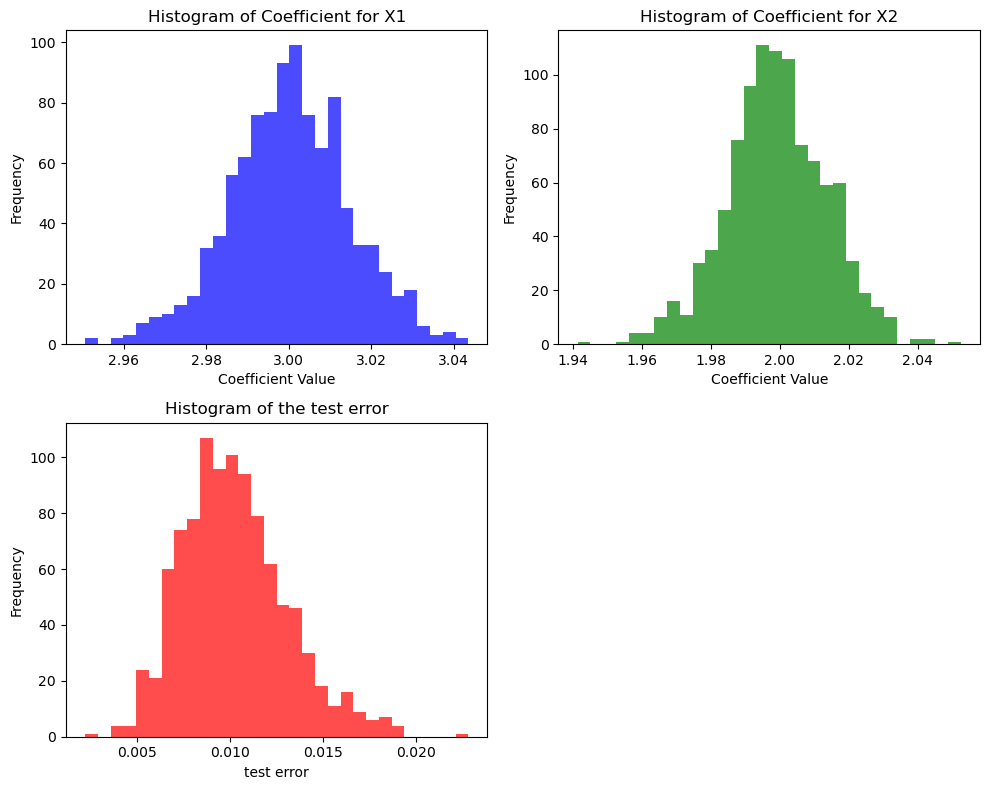

(2.370944382198573, 0.010256339594014513)

In [44]:
#with some correlation 
simu(corr=0.7)

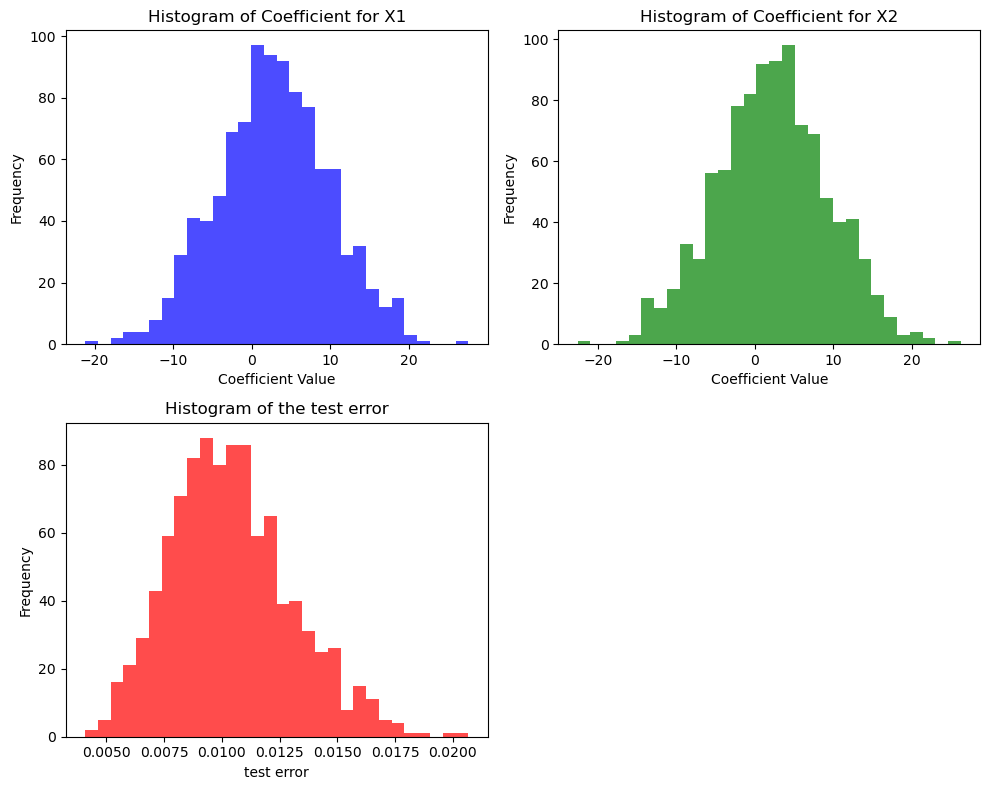

(1425.3364539444262, 0.010397342734381728)

In [45]:
# very very high correlation : catastrophe for the estimation of the coefficients
# but not so bad for the prediction...
simu(corr=0.999999)

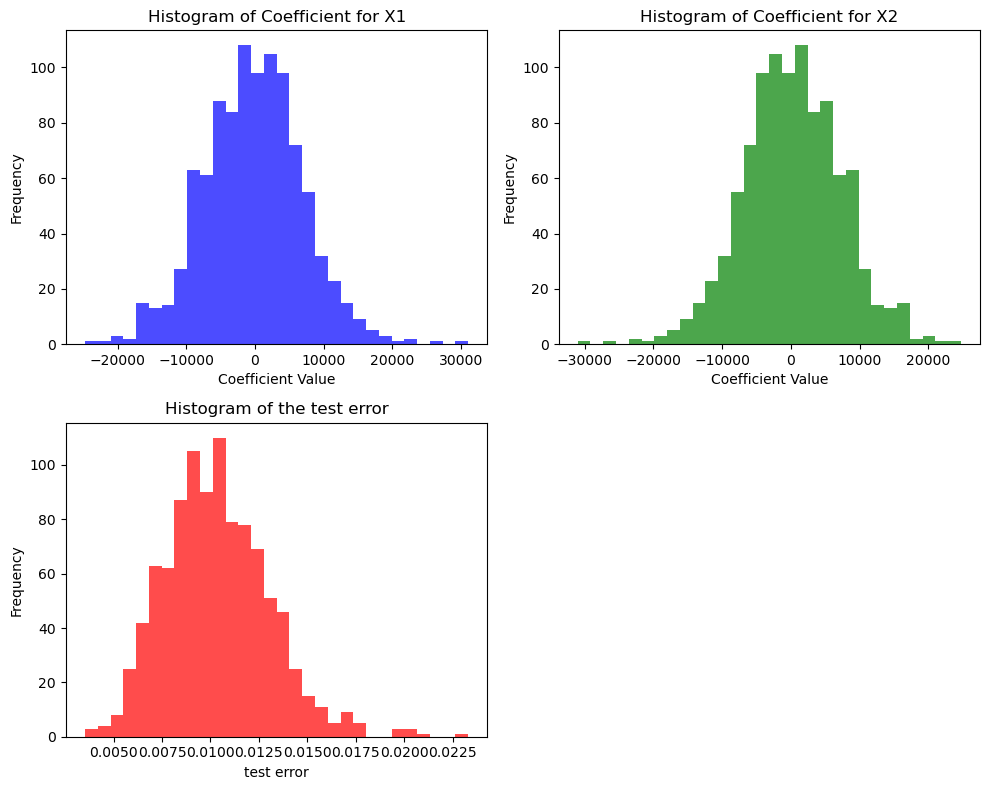

(1517576.9085788054, 0.010352633793923005)

In [56]:
simu(corr=0.999999999999)

**Same simulation, juste another design...**

In [98]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Set random seed for reproducibility



rng=np.random.default_rng(seed=4)

#big rho = big correlation. 
def simu2(n_samples=100,n_simulations=1000,rho=0):

    coefficients = []
    test_error=[]

    N=int(n_samples*1.3)
    
    for _ in range(n_simulations):
        # Generate synthetic data
        X1=rng.random(N)
        X2=rng.random(N)+rho*X1
        y = 3 * X1 + 2 * X2 + rng.normal(0, 0.1, N)
        X = np.column_stack((X1, X2))
        
        Xtrain=X[:n_samples,:]
        Xtest=X[n_samples:,:]
        ytrain=y[:n_samples]
        ytest=y[n_samples:]
    
        # Fit linear regression model
        model = LinearRegression().fit(Xtrain, ytrain)
        
        # Store coefficients
        coefficients.append(model.coef_)

        # prediction and test error
        ypred = model.predict(Xtest)
        test_error.append(mean_squared_error(ytest, ypred))
    
    coefficients = np.array(coefficients)
    test_error=np.array(test_error)
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.delaxes(axes[1, 1]) 

    axes[0,0].hist(coefficients[:, 0], bins=30, alpha=0.7, color='blue')
    axes[0,0].set_title('Histogram of Coefficient for X1')
    axes[0,0].set_xlabel('Coefficient Value')
    axes[0,0].set_ylabel('Frequency')

    axes[0,1].hist(coefficients[:, 1], bins=30, alpha=0.7, color='green')
    axes[0,1].set_title('Histogram of Coefficient for X2')
    axes[0,1].set_xlabel('Coefficient Value')
    axes[0,1].set_ylabel('Frequency')

    axes[1,0].hist(test_error, bins=30, alpha=0.7, color='red')
    axes[1,0].set_title('Histogram of the test error')
    axes[1,0].set_xlabel('test error')
    axes[1,0].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    return(np.linalg.eig(X.T@X)[0],test_error.mean())

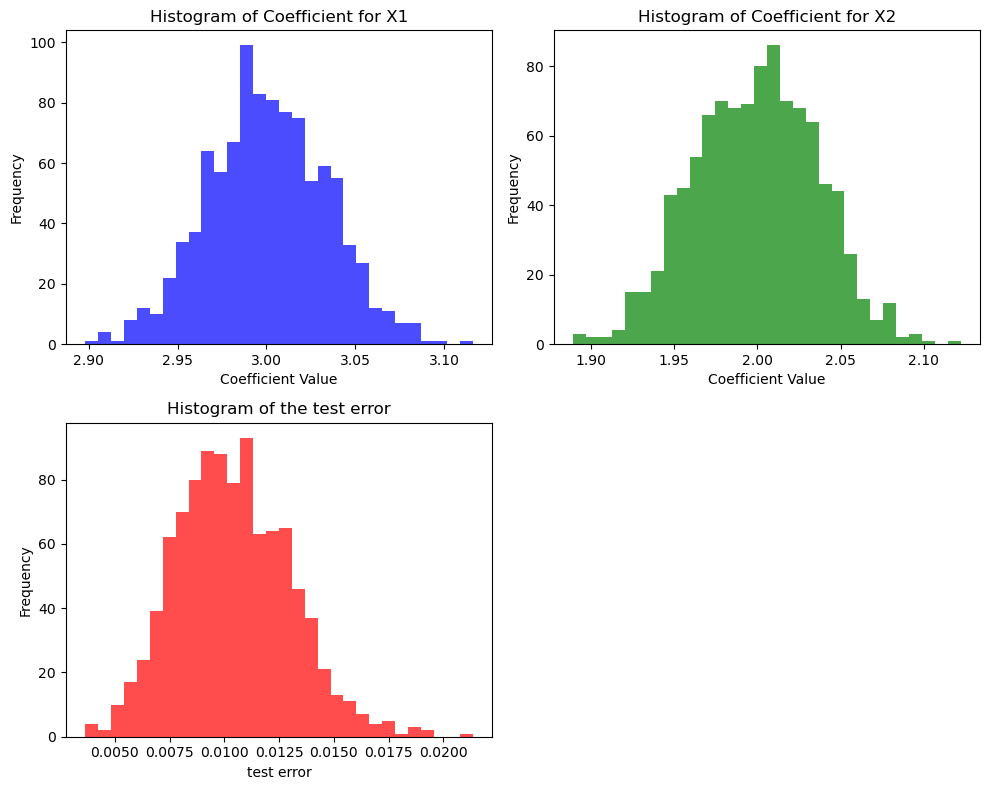

(array([66.26878673, 11.12548235]), 0.010402704803287921)

In [99]:
simu2(rho=0)

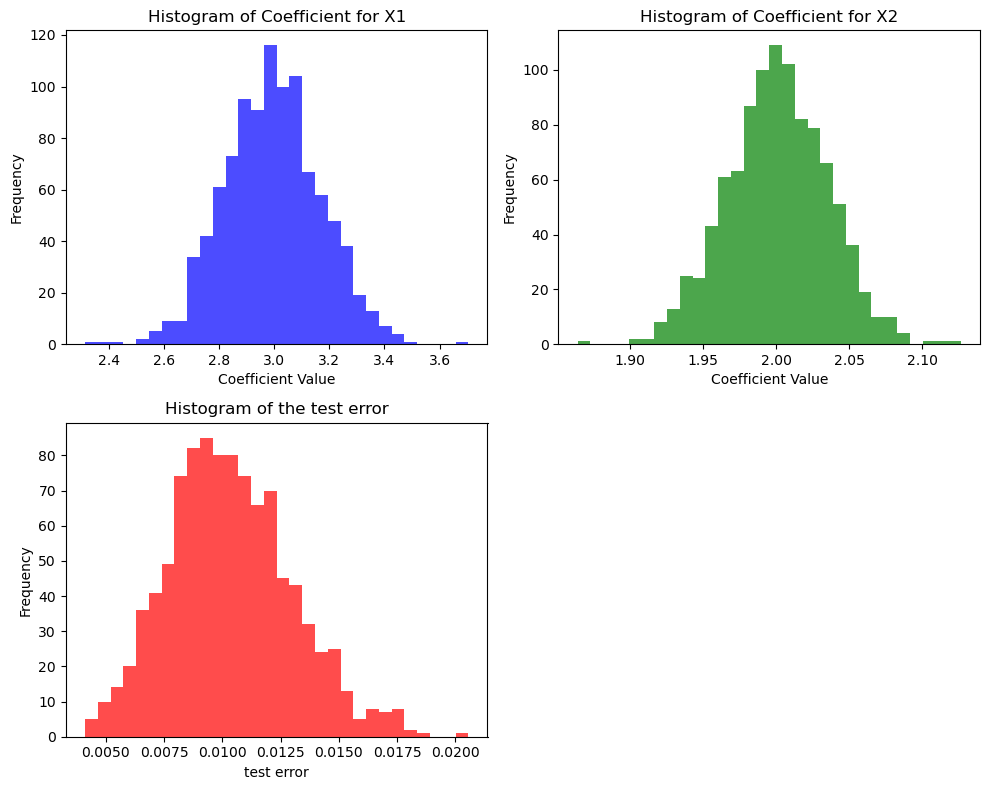

(array([5.20096826e-01, 1.50248323e+03]), 0.01036144055650596)

In [100]:
simu2(rho=5)

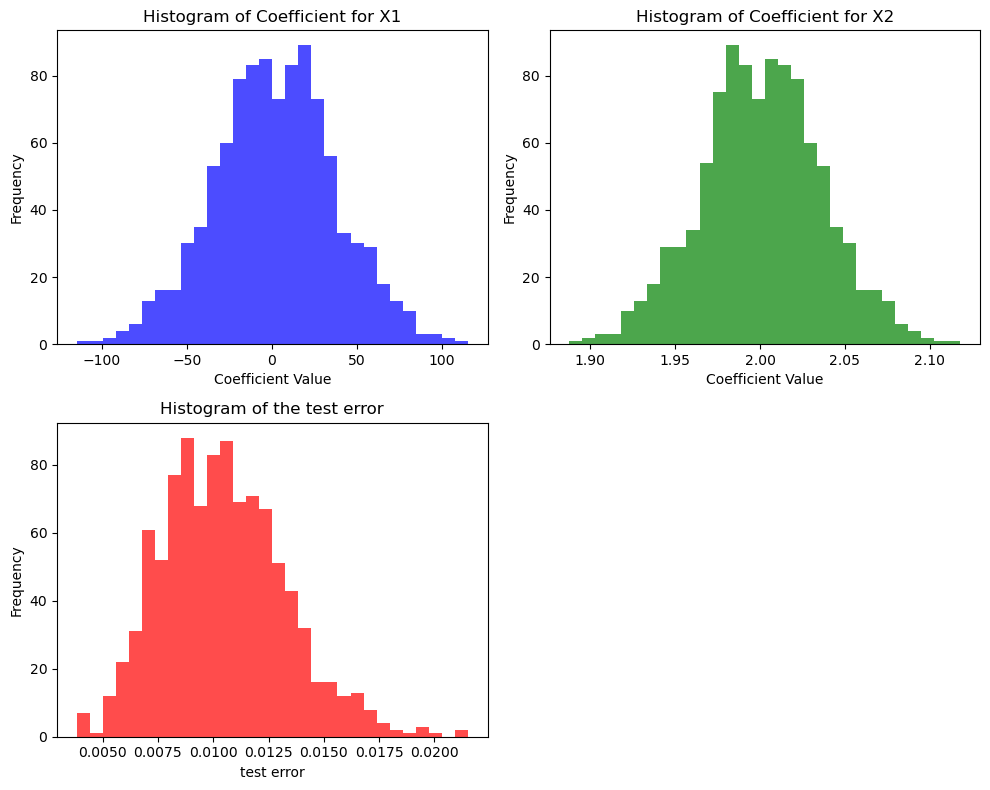

(array([1.86040998e-05, 4.54954155e+07]), 0.010463271254433842)

In [101]:
simu2(rho=1000)